# 在 AMD Radeon 显卡上跑 PyTorch：与 NVIDIA 的实际差别
> **学习建议**：开始本教程前，建议先学习 快速入门 https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html#， 了解张量操作、数据集与数据加载器、 数据转换、构建模型、自动求导、优化算法、保存和加载模型基本概念。

本教程回答一个具体的问题：一份原本在 NVIDIA 卡上写好的 PyTorch 代码，搬到 AMD Radeon 显卡上，到底要改哪里、不用改哪里？

本教程按照以下顺序——建张量、搭模型、简单训练、再到推理，每一步都对比一下 AMD 和 NVIDIA。结论先摆在前面：除了识别GPU的校验逻辑不一样，其余代码都一样，真正的差别几乎都在安装和环境这一层。

## 从本教程你可以学到什么

- 理解为什么在 AMD Radeon 卡上，PyTorch 代码里写的依然是 `cuda`，以及 ROCm / HIP 与 CUDA 的对应关系
- 判断手上的 PyTorch 到底是 ROCm 构建还是 CUDA 构建，并确认它能认出这块 AMD 卡
- 掌握两家在环境变量上的差异：`HIP_VISIBLE_DEVICES` 与 `CUDA_VISIBLE_DEVICES`、以及 AMD 特有的 `HSA_OVERRIDE_GFX_VERSION`
- 按平时写代码的顺序——建张量、搭模型、训练、推理——逐环节对比 AMD 与 NVIDIA 的写法，看清哪些要改、哪些照搬
- 学会在 AMD 卡上做显存与性能监控（`amd-smi`、`torch.cuda.memory_*`）、计时同步和混合精度（autocast）
- 用 ROCm 构建的 vLLM 跑通一个大模型推理示例

## 前置条件

本教程面向 AMD Radeon Cloud Notebook 环境编写。开始前，请确认平台和仓库设置如下。

### 平台

- AMD Radeon Cloud（radeon.anruicloud.com）
- 基础镜像：radeon-cloud-registry.cn-shanghai.cr.aliyuncs.com/admin/amd-oneclick-base:rocm7.2.1-py3.12-v20260416
- GitHub Repo URL: https://github.com/hongweig0422-ui/AMD-Course.git (创建template时填写)
- Notebook Path: amd_vs_nvidia/amd_vs_nvidia_pytorch/amd_vs_nvidia_pytorch_zh.ipynb

### 硬件

- **AMD Radeon PRO W7900**：本教程在 **AMD Radeon PRO W7900**（RDNA3，gfx1100，48GB 显存）上完成测试。

### 软件
推荐使用平台预装镜像，无需在 notebook 中重新安装以下软件、库：
- **ROCm 7.2.1**
- **Python 3.12.3**
- **PyTorch（ROCm 构建）**：建张量、搭模型、训练、推理这套主流程代码和 NVIDIA 完全一致。
- **vLLM（ROCm 构建）**：用于最后的大模型推理示例，接口和 CUDA 版一样。

## 一、先理解一件事：在 AMD 上，代码里写的还是 `cuda`

刚上手 AMD 卡的人几乎都会卡在同一个地方：明明是 AMD 卡，为什么代码里到处都是 `cuda`？

因为 ROCm 本来就是这么设计的。它提供了一套叫 HIP 的runtime，API 基本和 CUDA 一一对应；PyTorch 的 ROCm 构建又把 `torch.cuda.*` 这一整套接口接到了 HIP 上。所以在 AMD 卡上：

- `torch.cuda.is_available()` 返回 `True`
- `device = 'cuda'` 指向的就是你的 AMD GPU
- `tensor.to('cuda')`、`NeuralNetwork().to('cuda')`、`torch.cuda.synchronize()` 照常用

换句话说，训练和推理的主流程代码在两家卡上是一样的。需要留意的差别集中在安装、底层库、几个环境变量，以及个别算子的支持情况，后面遇到我会一一讲解。

## 二、确认 PyTorch 认得这块 AMD 卡

装完之后先跑一段代码，确认两件事：一是当前这个 PyTorch 到底是 ROCm 构建还是 CUDA 构建，二是它能不能看到 GPU。

判断构建类型有个简单办法：ROCm 构建里 `torch.version.hip` 有值、`torch.version.cuda` 是 `None`；CUDA 构建正好反过来。

In [ ]:
import sys, platform
import torch

print('Python      :', sys.version.split()[0])
print('平台        :', platform.platform())
print('PyTorch     :', torch.__version__)

# ROCm 构建：hip 有值、cuda 为 None；CUDA 构建则相反
print('version.hip :', torch.version.hip)
print('version.cuda:', torch.version.cuda)

# 即便是 AMD 卡，可用性判断也还是走 torch.cuda.*
print('cuda.is_available():', torch.cuda.is_available())

if torch.cuda.is_available():
    idx = torch.cuda.current_device()
    props = torch.cuda.get_device_properties(idx)
    print('GPU 数量    :', torch.cuda.device_count())
    print('设备名称    :', torch.cuda.get_device_name(idx))
    print('架构        :', getattr(props, 'gcnArchName', 'N/A'))  # W7900 应含 gfx1100
    print('显存(GB)    :', round(props.total_memory / 1024**3, 1))

Python      : 3.12.3
平台        : Linux-6.8.0-79-generic-x86_64-with-glibc2.39
PyTorch     : 2.9.1+gitff65f5b
version.hip : 7.2.53211-e1a6bc5663
version.cuda: None
cuda.is_available(): True
GPU 数量    : 1
设备名称    : AMD Radeon Graphics
架构        : gfx1100
显存(GB)    : 48.0


In [ ]:
# 命令行看卡：AMD 用 amd-smi，NVIDIA 用 nvidia-smi
!amd-smi || echo 'rocm-smi 不可用：当前可能不在 ROCm 环境'

+------------------------------------------------------------------------------+
| AMD-SMI 26.2.2+e1a6bc5663    amdgpu version: 6.14.14  ROCm version: 7.2.1    |
| VBIOS version: 00162356                                                      |
| Platform: Linux Baremetal                                                    |
|-------------------------------------+----------------------------------------|
| BDF                        GPU-Name | Mem-Uti   Temp   UEC       Power-Usage |
| GPU  HIP-ID  OAM-ID  Partition-Mode | GFX-Uti    Fan               Mem-Usage |
|=====================================+========================================|
| 0000:03:00.0    AMD Radeon Graphics | 0 %      33 °C   0            12/241 W |
|   0       0     N/A             N/A | 0 %     20.0 %          30731/49136 MB |
+-------------------------------------+----------------------------------------+
+------------------------------------------------------------------------------+
| Processes:                

In [ ]:
# 跨厂商通用写法：在 AMD(ROCm) 上，设备字符串依然是 'cuda'，不是 'rocm' 或 'hip'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('选定设备:', device)
# PyTorch 2.6+ 提供了更中立的 accelerator 接口（AMD / NVIDIA / XPU 通用）
if hasattr(torch, 'accelerator') and torch.accelerator.is_available():
    print('accelerator:', torch.accelerator.current_accelerator().type)

选定设备: cuda
accelerator: cuda


## 三、建张量：无差别

张量的创建、`dtype`、索引、运算、用 `.to()` 在设备间搬来搬去——这些写法在 AMD 和 NVIDIA 上完全一样。

唯一要习惯的一点：先把创建的张量放到 GPU 上，然后张量之间进行矩阵运算。`tensor.device` 打印出来是 `cuda:0`，而不是 `rocm:0` 或 `hip:0`。这只是沿用了 CUDA 的命名，东西是实实在在跑在 AMD 卡上的，底层的矩阵运算走的是 rocBLAS，而不是 NVIDIA 的 cuBLAS。

In [ ]:
# 直接在 GPU 上建张量
x = torch.rand(3, 4, device=device)

# 或者先在 CPU 建好再搬过去
y = torch.ones(3, 4).to(device)

print('x.device:', x.device)   # AMD 卡上依然显示 cuda:0
print('y.device:', y.device)
print('x.dtype :', x.dtype)

# GPU 上做矩阵乘法
z = x @ y.T
print('z.shape :', z.shape, '| z.device:', z.device)   #tuple(z.shape)

x.device: cuda:0
y.device: cuda:0
x.dtype : torch.float32
z.shape : torch.Size([3, 3]) | z.device: cuda:0


In [ ]:
# 直观演示：为什么结果要先 .cpu() 再交给 NumPy
# z 此刻在 GPU 上（cuda:0），NumPy 只认 CPU 内存，直接转会报错
try:
    arr = z.numpy()
    print('z.numpy() 直接成功 —— 说明 z 本来就在 CPU 上')
except Exception as e:
    print('z.numpy() 报错:', type(e).__name__)
    print('  原因:', e)

# 正确写法：先 .cpu() 把数据从显存搬回内存，再转 NumPy（AMD / NVIDIA 卡一致）
arr = z.cpu().numpy()
print('z.cpu().numpy() 成功 -> 类型:', type(arr).__name__, '| 形状:', arr.shape, '| dtype:', arr.dtype)

z.numpy() 报错: TypeError
  原因: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.
z.cpu().numpy() 成功 -> 类型: ndarray | 形状: (3, 3) | dtype: float32


### 指定用哪几张卡：环境变量名不一样

- NVIDIA 用 `CUDA_VISIBLE_DEVICES`
- AMD 用 `HIP_VISIBLE_DEVICES`

另外有个 AMD 特有的变量，解决的是“显卡架构对不对得上”：
`HSA_OVERRIDE_GFX_VERSION` 是在用非官方支持的消费级卡时，拿来“伪装”架构号的。只有当真实显卡和冒充对象架构足够接近（通常是同代）才行，否则轻则报错重则算出乱码。W7900 属于官方支持，现在用不上。 

**经典场景**：RX 6700 XT 的架构是 gfx1031，早期不在 ROCm 官方支持列表里，于是大家设 `HSA_OVERRIDE_GFX_VERSION=10.3.0`，让它假装成同属 RDNA2、官方支持的 gfx1030（RX 6800/6900）。因为是同一代架构，内核通用，就能跑起来。

In [ ]:
import os
for k in ['HIP_VISIBLE_DEVICES', 'HSA_OVERRIDE_GFX_VERSION']:
    print(f'{k:<24} =', os.environ.get(k, '(未设置)'))

HIP_VISIBLE_DEVICES      = (未设置)
HSA_OVERRIDE_GFX_VERSION = (未设置)


> **说明**：
AMD/ROCm 也支持用 `CUDA_VISIBLE_DEVICES` 来选卡。这是 HIP 故意做的“CUDA 兼容”设计——很多现成脚本/框架都是给 NVIDIA 卡写的、里面用 `CUDA_VISIBLE_DEVICES`，放到 AMD 卡上不用改就能跑。PyTorch-ROCm 底层就是 HIP，所以可以使用 `CUDA_VISIBLE_DEVICES`。

**经典场景**：假如服务器上有4张卡，设置`HIP_VISIBLE_DEVICES="1,3"`，PyTorch 只看到 2 张卡，且重新编号 → `cuda:0`=物理卡1，`cuda:1`=物理卡3，那么你使用的是1,3卡。
```python
import os
os.environ["HIP_VISIBLE_DEVICES"] = "1,3" # 一定要在 import torch 之前,否则不生效。
import torch
print("可见卡数:", torch.cuda.device_count()) #输出结果是2，说明生效。
```

## 四、搭模型：写法完全一样

定义 `nn.Module` 子类、堆各种层、写 `forward`、最后 `NeuralNetwork().to(device)`——和在 NVIDIA 上没有任何区别。

 `NeuralNetwork().to('cuda')` 之后，参数就进了 AMD 卡的显存，卷积和矩阵运算交给 MIOpen、rocBLAS 去做（NVIDIA 那边对应的是 cuDNN、cuBLAS）。这些对上层代码是透明的，我们感知不到。

In [ ]:
from torch import nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.linear_relu_stack(x)

model = NeuralNetwork().to(device)
print(model)
print('模型所在设备:', next(model.parameters()).device)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)
模型所在设备: cuda:0


## 五、准备数据集：无差别

用 torchvision 自带的 FashionMNIST：6 万张训练、1 万张测试，28×28 的灰度服装图，共 10 类。数据加载、`DataLoader`、`transforms.v2` 这套预处理在两家卡上都一样。首次运行会自动下载约 30MB 到 `./data`。

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

# ToImage 转成图像张量，ToDtype(scale=True) 转 float32 并归一化到 [0,1]
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

training_data = datasets.FashionMNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='data', train=False, download=True, transform=transform)

batch_size = 64
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print('一个 batch 特征 [N, C, H, W]:', tuple(X.shape))
    print('一个 batch 标签           :', tuple(y.shape), '| dtype:', y.dtype)
    break

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

一个 batch 特征 [N, C, H, W]: (64, 1, 28, 28)
一个 batch 标签           : (64,) | dtype: torch.int64


## 六、简单训练一下，给推理准备权重：无差别

推理得有真实权重才有意义，所以先训几个 epoch。训练这部分也不用改：`loss.backward()`、`optimizer.step()`、`optimizer.zero_grad()` 三步，加上 `model.train()` / `model.eval()` 的切换，还有数据 `.to(device)`——都和 NVIDIA 一样。想快就把 epoch 调小，想提高准确率就调大。

In [ ]:
import time

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)          # 数据搬到 GPU，写法同 NVIDIA
        loss = loss_fn(model(X), y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if batch % 200 == 0:
            print(f'  loss {loss.item():>7f}  [{batch * batch_size + len(X):>5d}/{size:>5d}]')

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size, num_batches = len(dataloader.dataset), len(dataloader)
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    print(f'测试集: 准确率 {100*correct/size:>0.1f}%, 平均损失 {test_loss/num_batches:>8f}')

epochs = 4
t0 = time.time()
for t in range(epochs):
    print(f'Epoch {t+1}')
    print('-------------------------------')
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print(f'训练完成，用时 {time.time() - t0:.1f}s')

# 只存 state_dict，推荐做法，和 NVIDIA 一致
torch.save(model.state_dict(), 'fashion_mnist_w7900.pth')
print('权重已保存到 fashion_mnist_w7900.pth')

Epoch 1
-------------------------------
  loss 2.306130  [   64/60000]
  loss 2.278548  [12864/60000]
  loss 2.242152  [25664/60000]
  loss 2.218081  [38464/60000]
  loss 2.160464  [51264/60000]
测试集: 准确率 35.1%, 平均损失 2.155488
Epoch 2
-------------------------------
  loss 2.169300  [   64/60000]
  loss 2.138405  [12864/60000]
  loss 2.049313  [25664/60000]
  loss 2.017844  [38464/60000]
  loss 1.964840  [51264/60000]
测试集: 准确率 54.8%, 平均损失 1.881060
Epoch 3
-------------------------------
  loss 1.865860  [   64/60000]
  loss 1.754454  [12864/60000]
  loss 1.730362  [25664/60000]
  loss 1.580663  [38464/60000]
  loss 1.501444  [51264/60000]
测试集: 准确率 60.2%, 平均损失 1.509095
Epoch 4
-------------------------------
  loss 1.430400  [   64/60000]
  loss 1.423490  [12864/60000]
  loss 1.327167  [25664/60000]
  loss 1.329929  [38464/60000]
  loss 1.259068  [51264/60000]
测试集: 准确率 61.5%, 平均损失 1.247283
训练完成，用时 26.2s
权重已保存到 fashion_mnist_w7900.pth


## 七、推理：无差别

这份 Notebook 的重点。标准推理流程就四步：重建模型结构、加载权重、切到 `eval()`、在 `torch.no_grad()` 下做前向。这一整套在 AMD 和 NVIDIA 上没有区别。加载权重时带上 `weights_only=True` 是安全上的好习惯，两家卡都一样。

In [ ]:
# 重建同结构模型并加载权重，模拟真实部署
infer_model = NeuralNetwork().to(device)
infer_model.load_state_dict(torch.load('fashion_mnist_w7900.pth', weights_only=True))
infer_model.eval()   # 推理前记得切 eval

# 拿测试集第一张图做单样本推理
x, y = test_data[0]
with torch.no_grad():
    x = x.to(device)
    pred = infer_model(x.unsqueeze(0))     # 补上 batch 维 -> [1, 1, 28, 28]
    predicted = classes[pred[0].argmax(0)]
print(f'预测: {predicted}  |  真实: {classes[y]}')

预测: Ankle boot  |  真实: Ankle boot


### 批量推理与计时

在 GPU 上计时有个通用的坑：GPU 调用是异步下发的，不加同步的话，测到的其实是“发指令”的时间，不是真正算完的时间。所以计时前后都要 `torch.cuda.synchronize()`——这个接口在 AMD 上照样管用。

In [ ]:
infer_model.eval()
correct = total = 0

if device == 'cuda':
    torch.cuda.synchronize()     # 计时前先同步
t0 = time.time()
with torch.no_grad():
    for X, y in test_dataloader:
        preds = infer_model(X.to(device)).argmax(1).cpu()
        correct += (preds == y).sum().item()
        total += y.size(0)
if device == 'cuda':
    torch.cuda.synchronize()     # 算完再同步，计时才准
elapsed = time.time() - t0

print(f'整测试集 {total} 张，用时 {elapsed*1000:.1f} ms，吞吐 {total/elapsed:,.0f} 张/秒')
print(f'准确率 {100*correct/total:.1f}%')

整测试集 10000 张，用时 758.5 ms，吞吐 13,184 张/秒
准确率 61.5%


## 八、显存与性能监控：命令行有差别

差别很简单：命令行工具换个名字，Python 接口完全照搬。

| 用途 | NVIDIA | AMD Radeon |
| --- | --- | --- |
| 命令行看 GPU | `nvidia-smi` | `amd-smi` |
| Python 查显存 | `torch.cuda.memory_allocated()` | 一样 |
| 清空缓存 | `torch.cuda.empty_cache()` | 一样 |

> **说明**：
- memory_allocated()：当前真正被张量占用的显存。推理后跑，看到的是「推理残留 + 已加载模型」占的量。
- max_memory_allocated()：从上次 reset_peak_memory_stats() 到现在的峰值。放在推理后，才能测到推理过程中的显存峰值。
- memory_reserved()：memory_reserved()  =  memory_allocated()  +  空闲的缓存块。建一个张量 → PyTorch 发现池子里没空位 → 一次性向系统申请一大块显存（reserved 增加），切一份显存给创建的张量（allocated 增加），张量释放后 → 这份显存归回池子（allocated 减少），但整块显存仍然在PyTorch 手里（reserved 不变）。
- reset_peak_memory_stats()：把 PyTorch 内部记的峰值计数器归零，下一次推理的 max_memory_allocated()重新开始计算峰值。
- empty_cache()：把空闲的缓存块还给系统。

In [ ]:
# 显存这套接口在 AMD 上直接复用 torch.cuda.*
if device == 'cuda':
    print(f'已分配显存 : {torch.cuda.memory_allocated()/1024**2:.1f} MB')
    print(f'峰值显存   : {torch.cuda.max_memory_allocated()/1024**2:.1f} MB')
    print(f'缓存显存   : {torch.cuda.memory_reserved()/1024**2:.1f} MB')
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()   # 释放缓存，用法同 NVIDIA
    print('已清缓存、重置峰值统计')
else:
    print('当前在 CPU 上，跳过显存统计')

已分配显存 : 157.1 MB
峰值显存   : 159.7 MB
缓存显存   : 176.0 MB
已清缓存、重置峰值统计


> **说明**：torch.cuda.memory_allocated()与amd-smi区别

|     | torch.cuda.memory_allocated() | amd-smi / nvidia-smi |
| --- | --- | --- |
| 统计对象 | 只算当前张量实际占用的显存 | 整卡占用的物理显存（包括张量占用，PyTorch 缓存但未使用的块，驱动开销，hip）|

In [ ]:
# 运行训练或推理时看 GPU 占用（ NVIDIA 对应换成 nvidia-smi）,实时监控，每 1 秒刷新一次
!watch -n 1 amd-smi || echo 'amd-smi 不可用'

>?47hEvery 1.0s: amd-smiu-641-a4c817bd: Sun Jul 12 18:18:46 2026+------------------------------------------------------------------------------+| AMD-SMI 26.2.2+e1a6bc5663    amdgpu version: 6.14.14  ROCm version: 7.2.1    || VBIOS version: 00162356|| Platform: Linux Baremetal||-------------------------------------+----------------------------------------|| BDFGPU-Name | Mem-Uti   Temp   UECPower-Usage || GPU  HIP-ID  OAM-ID  Partition-Mode | GFX-Uti    FanMem-Usage ||=====================================+========================================|| 0000:03:00.0    AMD Radeon Graphics | 0 %33 °C   014/241 W ||   00     N/AN/A | 1 %     20.0 %31240/49136 MB |+-------------------------------------+----------------------------------------++------------------------------------------------------------------------------+| Processes:||  GPUPID  Process NameGTT_MEM  VRAM_MEM  MEM_USAGE     CU % ||==============================================================================||    03550  N/A0.0 B

## 九、混合精度（autocast）：无差别

W7900 是 RDNA3，原生支持 bfloat16，推理时拿来提速很合适。写法基本没差别，需要注意的点：`torch.autocast(device_type='cuda', ...)` 里的 `device_type`，在 AMD 上还是填 `'cuda'`——又是 ROCm 沿用 CUDA 命名的地方。

In [ ]:
infer_model.eval()
sample, _ = next(iter(test_dataloader))
sample = sample.to(device)

with torch.no_grad():
    with torch.autocast(device_type=device, dtype=torch.bfloat16):   # A 卡这里也是 'cuda'
        out = infer_model(sample)
print('autocast 输出 dtype:', out.dtype)

autocast 输出 dtype: torch.bfloat16


## 十、附：用 vLLM 跑大模型推理（可选）：在环境层有差别

前面是我们自己训练出来的.pth小模型。既然主题是推理，顺带看看大模型：环境里装的是 ROCm 构建的 vLLM，接口和 CUDA 版一样，`LLM(...)`、`SamplingParams`、`llm.generate(...)` 都不用改。W7900 的 48GB 显存放下 7B 级别的模型没问题，下面为了跑得快用了个小模型。

差别依旧在环境这层：因为装的是 ROCm 版 vLLM；底层的 attention kernel 由 vLLM 按平台自动选（NVIDIA 上是 FlashAttention 那套，AMD 上是 ROCm 的移植实现，把 FlashAttention 的思路移植到 AMD 平台，这通常基于 Composable Kernel 或 Triton 重写。虽然算法思想一样,但代码是另一套人重新实现的）。
>**说明**:"attention kernel"：Transformer 模型里最核心、最耗算力的一步是 注意力(attention) 计算。kernel(核函数)指的是真正跑在 GPU 上的那段底层计算代码。所以 "attention kernel" = "在 GPU 上执行注意力计算的那段底层实现"。

下步操作要联网下模型、也比较吃显存，按需运行。本教程显存占用大概在3000多MB。
下载模型需要安装 modelscope：

In [ ]:
!pip install "modelscope==1.37.0" --force-reinstall

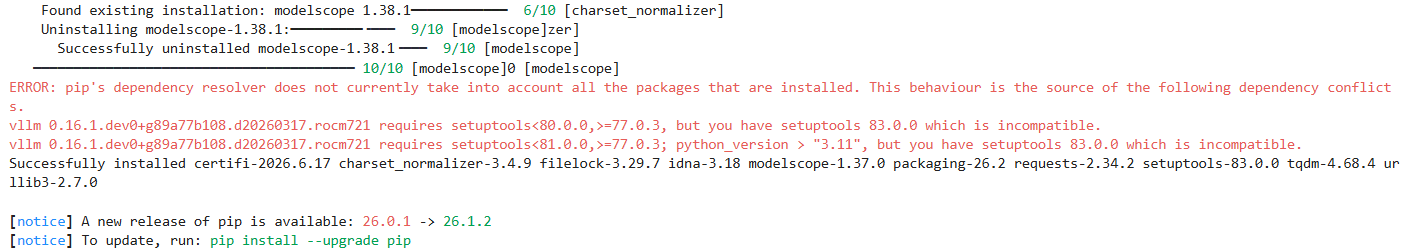

In [ ]:
import os
# 从魔搭社区(ModelScope)下载模型，国内速度更快。
# 必须在 import vllm 之前设置，否则不生效。
os.environ['VLLM_USE_MODELSCOPE'] = 'True'

from vllm import LLM, SamplingParams

# 模型名用魔搭仓库 id（Qwen 官方在魔搭的 id 与 HF 一致）
# 小模型保证快速跑通；显存够的话可换成 Qwen/Qwen2.5-7B-Instruct 等
llm = LLM(model='Qwen/Qwen2.5-1.5B-Instruct', dtype='bfloat16', gpu_memory_utilization=0.3)

prompts = ['用一句话解释什么是 GPU。', '给 AMD 显卡写一句宣传语。']
sampling_params = SamplingParams(temperature=0.7, top_p=0.9, max_tokens=128)

for o in llm.generate(prompts, sampling_params):
    print('问:', o.prompt)
    print('答:', o.outputs[0].text.strip())
    print('-' * 40)

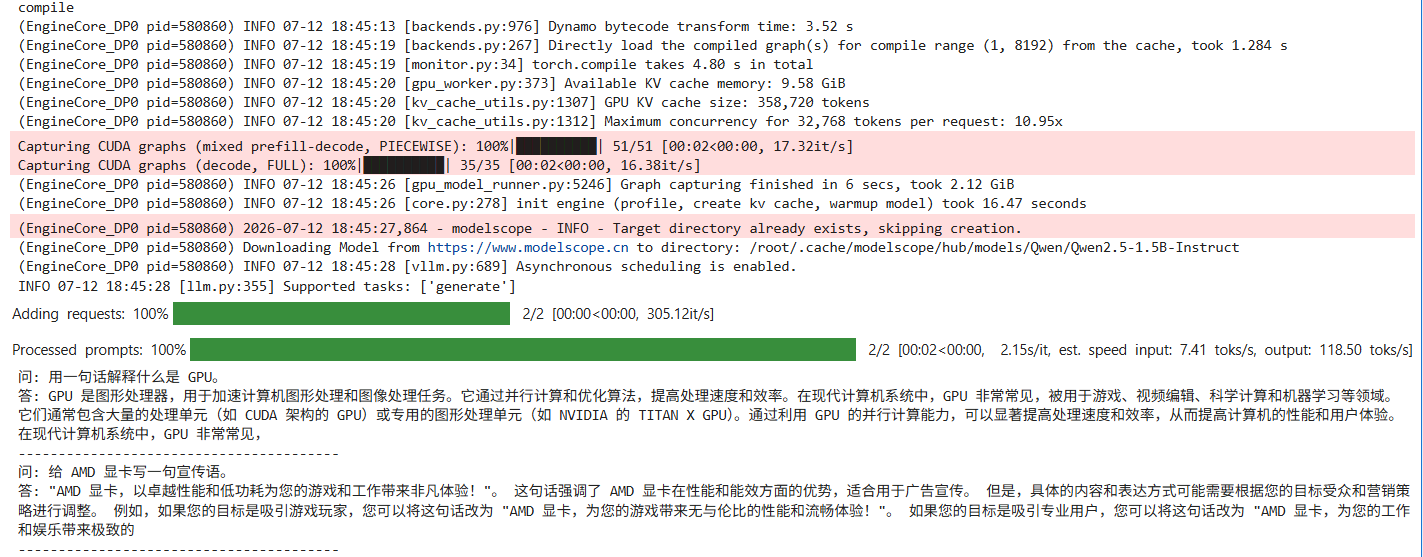

## 十一、小结：AMD 和 NVIDIA 到底差在哪

一句话：主流程代码基本照搬，差别几乎都在环境层，不在代码层。

| 环节 | NVIDIA (CUDA) | AMD Radeon (ROCm) | 代码要改吗 |
| --- | --- | --- | --- |
| 安装的轮子 | cu12x 构建 | rocm7.x 构建 | 装对就行 |
| 判断构建类型 | `torch.version.cuda` 有值 | `torch.version.hip` 有值 | 校验逻辑略变 |
| 可用性判断 | `torch.cuda.is_available()` | 一样 | 否 |
| 设备字符串 | `'cuda'` | 还是 `'cuda'` | 否 |
| 建张量 / 搬运 | `.to('cuda')` | 一样 | 否 |
| 搭模型 | `model.to('cuda')` | 一样 | 否 |
| 训练循环 | backward/step/zero_grad | 一样 | 否 |
| 推理流程 | eval + no_grad | 一样 | 否 |
| 计时同步 | `torch.cuda.synchronize()` | 一样 | 否 |
| 显存接口 | `torch.cuda.memory_*` | 一样 | 否 |
| 混合精度 | `autocast(device_type='cuda')` | 还是填 `'cuda'` | 否 |
| 底层库 | cuDNN / cuBLAS | MIOpen / rocBLAS | 透明，看不见、无需感知 |
| 指定多卡 | `CUDA_VISIBLE_DEVICES` | `HIP_VISIBLE_DEVICES` | 改环境变量 |
| 命令行看卡 | `nvidia-smi` | `amd-smi` | 运维命令 |
| 大模型推理 | vLLM (cuda) | vLLM (rocm) | 装对构建即可(安装 vLLM 时，要装和你显卡平台匹配的那个构建版本) |


## 十二、课后测验

读完全文后，试着回答下面 3 道题，检验一下你是否真的搞清了 AMD 和 NVIDIA 在 PyTorch 上的差别。建议先自己想清楚，再展开看答案解析。

---

**第 1 题（单选）**

在一台装了 AMD Radeon 显卡、ROCm 构建 PyTorch 的机器上，下面哪一行代码的行为**和 NVIDIA 卡不同**、需要改动？

- A. `device = 'cuda' if torch.cuda.is_available() else 'cpu'`
- B. `model.to('cuda')`
- C. `os.environ['CUDA_VISIBLE_DEVICES'] = '0'`
- D. `with torch.autocast(device_type='cuda', dtype=torch.bfloat16): ...`

<details>
<summary>点击查看答案与解析</summary>

**答案：C**

ROCm 通过 HIP 把 `torch.cuda.*` 整套接口都接了过来，所以在 AMD 卡上设备字符串仍然写 `'cuda'`、`torch.cuda.is_available()` 返回 `True`、`autocast` 的 `device_type` 也照样填 `'cuda'`——A、B、D 三项都无需改动。唯独控制“程序能看到哪几张卡”的环境变量名不同：NVIDIA 用 `CUDA_VISIBLE_DEVICES`，AMD 要用 `HIP_VISIBLE_DEVICES`。因此 C 是需要改的那一项。

</details>

---

**第 2 题（单选）**

你怀疑同事在 AMD 卡上误装了 CUDA 版的 PyTorch。最可靠的判断依据是？

- A. `torch.cuda.is_available()` 返回 `True` 就说明装对了
- B. `torch.version.hip` 有值且 `torch.version.cuda` 为 `None`，说明是 ROCm 构建
- C. `tensor.device` 打印出 `cuda:0` 就说明是 CUDA 构建
- D. 能 `import torch` 成功就说明构建正确

<details>
<summary>点击查看答案与解析</summary>

**答案：B**

区分构建类型的可靠办法是看版本属性：ROCm 构建里 `torch.version.hip` 有值、`torch.version.cuda` 为 `None`；CUDA 构建正好相反。

- A 错：在 A 卡上误装 CUDA 版 torch 时，`torch.cuda.is_available()` 反而会返回 `False`，不能作为“装对”的证据。
- C 错：AMD 卡上张量的 `.device` 沿用 CUDA 命名，同样显示 `cuda:0`，并不能区分构建类型。
- D 错：能 import 只说明包装上了，说明不了是哪种构建、更说明不了能否用 GPU。

</details>

---

**第 3 题（单选）**

在 GPU 上给推理循环计时时，代码在计时前后各加了一次 `torch.cuda.synchronize()`。关于这样做的原因和它在 AMD 卡上的表现，下面哪个说法是**正确**的？

- A. GPU 调用是异步下发的，不同步会把“发指令”的时间当成真实耗时；该接口在 AMD 上照样能用
- B. 同步是为了清空显存缓存，测完后才能释放显存；该接口只在 NVIDIA 上有效
- C. AMD 卡上要改用 `torch.hip.synchronize()`，`torch.cuda.synchronize()` 会报错
- D. GPU 调用本来就是同步的，加 `synchronize()` 只是为了代码好看，删掉也不影响计时准确性

<details>
<summary>点击查看答案与解析</summary>

**答案：A**

GPU 的调用是**异步下发**的：CPU 把算子指令丢给 GPU 后会立刻返回，并不等 GPU 真正算完。如果不同步，`time.time()` 测到的只是“发指令”的时间，而非真实计算耗时，结果会偏小、不准确。正确做法是计时**前**先 `synchronize()` 拿到干净起点，计时**后**再 `synchronize()` 等这一轮真正算完。而且 ROCm 沿用了 `torch.cuda.*` 命名，`torch.cuda.synchronize()` 在 A 卡和 N 卡上写法、作用完全一致，所以 A 正确。

- B 错：`synchronize()` 只负责等待 GPU 完成，和释放显存缓存（那是 `empty_cache()` 的活）无关，且它在两家卡上都有效。
- C 错：AMD 上并没有 `torch.hip.synchronize()`，仍然用 `torch.cuda.synchronize()`。
- D 错：GPU 调用是异步的，删掉同步会导致计时严重失真。

</details>